<a href="https://colab.research.google.com/github/Dheepdata/Melting-Point-in-GNN/blob/main/MeltingPoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melting Point of chemical molecules using Graph Neural Network

##### Made use of BradleyMeltingPointDataset for the model.

## Downloading necessary libraries

In [ ]:
!pip install "numpy<2.0"


In [ ]:
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 41.7 MB/s eta 0:00:00


In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
# Install PyTorch Geometric dependencies and core
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 6.7 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.1 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.1/774.1 kB 7.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.3 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

Thu Sep 18 06:33:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
## Importing necessary libraries
import pandas as pd
import rdkit
import scipy
from rdkit import Chem
from rdkit.Chem import Draw
import torch
import matplotlib.pyplot as plt
import torch_geometric

/usr/local/lib/python3.12/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.12/dist-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cpu.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/usr/local/lib/python3.12/dist-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cpu.so: undefined symbol: _ZN5t

## Uploading the dataset from google drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [ ]:
df = pd.read_csv("/content/gdrive/MyDrive/MeltingPointDataset.csv")
df = df[['name','smiles','mpC']]
df

,name,smiles,mpC
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0
...,...,...,...
28640,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
28641,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
28642,xanthene,c1ccc2c(c1)Cc3ccccc3O2,101.5
28643,Xanthene,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


In [ ]:
df

,name,smiles,mpC
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0
...,...,...,...
28640,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
28641,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
28642,xanthene,c1ccc2c(c1)Cc3ccccc3O2,101.5
28643,Xanthene,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


In [ ]:
df['name'] = df['name'].str.lower()
df['name'].duplicated().sum()/len(df)

0.16201780415430267

In [ ]:
df['smiles'].duplicated().sum()/len(df)

0.16222726479315763

In [ ]:
df_new= df.drop_duplicates(subset=['name','smiles'], keep='first', inplace=False, ignore_index=False)

In [ ]:
df_new.shape

(26244, 3)

In [ ]:
df_new

,name,smiles,mpC
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0
...,...,...,...
28634,veratraldehyde,COc1cc(ccc1OC)C=O,43.0
28635,warfarin,CC(=O)CC(C\1=C(/O)c2ccccc2OC/1=O)c3ccccc3,161.0
28640,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
28643,xanthene,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


In [ ]:
df_new = df_new.reset_index(drop=True)
df_new

,name,smiles,mpC
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0
...,...,...,...
26239,veratraldehyde,COc1cc(ccc1OC)C=O,43.0
26240,warfarin,CC(=O)CC(C\1=C(/O)c2ccccc2OC/1=O)c3ccccc3,161.0
26241,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5
26242,xanthene,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0


## Cleaning up the datasets

#### We are kekulising the smiles so as to use it

In [ ]:
def kekule_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles, sanitize=False)
        Chem.SanitizeMol(mol)  # Run checks
        Chem.Kekulize(mol, clearAromaticFlags=True)
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        return None  # or log: f"{smiles} --> {e}"


In [ ]:
df_new["kekule"] = df_new["smiles"].apply(kekule_smiles)
df_new['kekule']

[06:51:49] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 11 12 13 15 16 17 18 19 22 23 24
[06:51:49] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 7 8 10 11 12 13 15 16 17 19
[06:51:49] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 6 7 8 9 11 12 13 15 16 17 18
[06:51:49] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 11 12 13 15 16 17 18 19 21 22 23
[06:51:49] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 11 12 13 15 16 17 18 19 20 21 22
[06:51:50] Explicit valence for atom # 20 C, 5, is greater than permitted
[06:51:50] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24
[06:51:50] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 23
[06:51:50] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[06:51:50] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[06:51:50] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[06:51:50] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[06:51:50] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 

,kekule
0,O=[N+]([O-])C1=CC=C(CC2=CC=CC=N2)C([N+](=O)[O-...
1,NC1=CC=CC=C1N1CCCCC1
2,C1=CN=C(N2CCNCC2)N=C1
3,OC1=CC=CC=C1N1CCNCC1
4,NCCC1=CCCCC1
...,...
26239,COC1=CC=C(C=O)C=C1OC
26240,CC(=O)CC(C1=CC=CC=C1)C1=C(O)C2=CC=CC=C2OC1=O
26241,C1=CC=C2OC3=CC=CC=C3CC2=C1
26242,C1=CC=C2OC3=CC=CC=C3CC2=C1


In [ ]:
null_count = df_new['kekule'].isna().sum()
print(f"Number of null values in the kekule column: {null_count}")

Number of null values in the kekule column: 279


##### Dropping the null values from the kekulised smiles column

In [ ]:
df_new = df_new.dropna(subset=['kekule'])
df_new = df_new.reset_index(drop=True)
df_new

,name,smiles,mpC,kekule
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,O=[N+]([O-])C1=CC=C(CC2=CC=CC=N2)C([N+](=O)[O-...
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,NC1=CC=CC=C1N1CCCCC1
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,C1=CN=C(N2CCNCC2)N=C1
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,OC1=CC=CC=C1N1CCNCC1
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,NCCC1=CCCCC1
...,...,...,...,...
25960,veratraldehyde,COc1cc(ccc1OC)C=O,43.0,COC1=CC=C(C=O)C=C1OC
25961,warfarin,CC(=O)CC(C\1=C(/O)c2ccccc2OC/1=O)c3ccccc3,161.0,CC(=O)CC(C1=CC=CC=C1)C1=C(O)C2=CC=CC=C2OC1=O
25962,xanthene,c1ccc2c(c1)Cc3ccccc3O2,100.5,C1=CC=C2OC3=CC=CC=C3CC2=C1
25963,xanthene,C1C2=CC=CC=C2OC3=CC=CC=C31,101.0,C1=CC=C2OC3=CC=CC=C3CC2=C1


In [ ]:
df_new["kekule"][0]

'O=[N+]([O-])C1=CC=C(CC2=CC=CC=N2)C([N+](=O)[O-])=C1'

##### converting the smiles to mol file

In [ ]:
df_new["Mol"] = df_new["kekule"].apply(Chem.MolFromSmiles)
df_new['Mol']

,Mol
0,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fc9e0>
1,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fcdd0>
2,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fcac0>
3,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fca50>
4,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fc820>
...,...
25960,<rdkit.Chem.rdchem.Mol object at 0x7f25b3fbc660>
25961,<rdkit.Chem.rdchem.Mol object at 0x7f25b3fbc6d0>
25962,<rdkit.Chem.rdchem.Mol object at 0x7f25b3fbc740>
25963,<rdkit.Chem.rdchem.Mol object at 0x7f25b3fbc7b0>


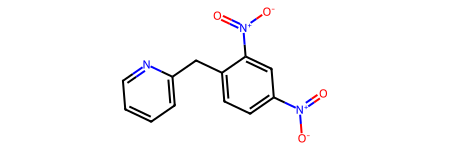

In [ ]:
df_new["Mol"][0]

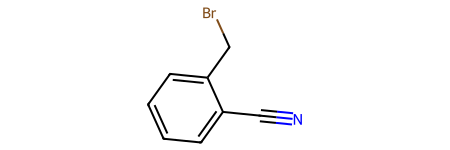

In [ ]:
df_new["Mol"][1000]

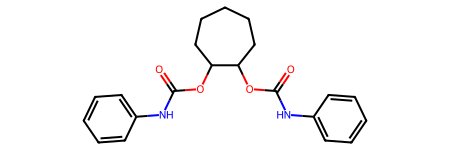

In [ ]:
df_new["Mol"][10000]

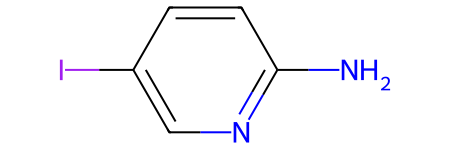

In [ ]:
df_new["Mol"][2000]

##### Indexing the diffrent atoms present in a molecule

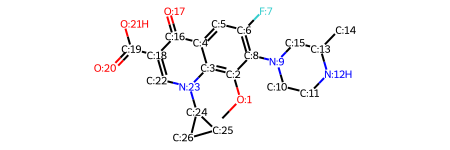

In [ ]:
def get_idx(molecule):
    for atom in molecule.GetAtoms():
        #print (atom)
        idx_atom = atom.GetIdx()
        #print(idx_atom)
        atom.SetAtomMapNum(idx_atom)
    return (molecule)

df_new["idx_mol"] = df_new["Mol"].apply(lambda x: get_idx(x))
df_new["idx_mol"][15892]

##### Finding out the edges of the molecule

In [ ]:
def find_edge(molecule):
    edges = []
    for bond in molecule.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edges.append([i,j])
        edges.append([j,i])
    return edges

df_new['edge'] = df_new['idx_mol'].apply(lambda x:find_edge(x))
df_new["edge"][15892]

[[0, 1],
 [1, 0],
 [1, 2],
 [2, 1],
 [2, 3],
 [3, 2],
 [3, 4],
 [4, 3],
 [4, 5],
 [5, 4],
 [5, 6],
 [6, 5],
 [6, 7],
 [7, 6],
 [6, 8],
 [8, 6],
 [8, 9],
 [9, 8],
 [9, 10],
 [10, 9],
 [10, 11],
 [11, 10],
 [11, 12],
 [12, 11],
 [12, 13],
 [13, 12],
 [13, 14],
 [14, 13],
 [13, 15],
 [15, 13],
 [4, 16],
 [16, 4],
 [16, 17],
 [17, 16],
 [16, 18],
 [18, 16],
 [18, 19],
 [19, 18],
 [19, 20],
 [20, 19],
 [19, 21],
 [21, 19],
 [18, 22],
 [22, 18],
 [22, 23],
 [23, 22],
 [23, 24],
 [24, 23],
 [24, 25],
 [25, 24],
 [25, 26],
 [26, 25],
 [8, 2],
 [2, 8],
 [15, 9],
 [9, 15],
 [26, 24],
 [24, 26],
 [23, 3],
 [3, 23]]

##### Gettign the adjacency matrix

In [ ]:
from rdkit.Chem import rdmolops

In [ ]:
def adj_matrix(molecule):
    x = rdkit.Chem.rdmolops.GetAdjacencyMatrix(molecule)

    return torch.tensor(x, dtype = torch.long)# check with google tensor?

df_new["adj_matrix"] = df_new["idx_mol"].apply(lambda x: adj_matrix(x))
df_new["adj_matrix"][2000]

tensor([[0, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 1],
        [0, 1, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 1],
        [0, 1, 0, 0, 0, 0, 1, 0]])

In [ ]:
df_new["edge"][1]

[[0, 1],
 [1, 0],
 [1, 2],
 [2, 1],
 [2, 3],
 [3, 2],
 [3, 4],
 [4, 3],
 [4, 5],
 [5, 4],
 [5, 6],
 [6, 5],
 [6, 7],
 [7, 6],
 [7, 8],
 [8, 7],
 [8, 9],
 [9, 8],
 [9, 10],
 [10, 9],
 [10, 11],
 [11, 10],
 [11, 12],
 [12, 11],
 [6, 1],
 [1, 6],
 [12, 7],
 [7, 12]]

In [ ]:
# x = list(zip([1,2],[2,1],[2,3],[3,4]))
# x

In [ ]:
# row, col = list(zip(*df_new["edge"][2000]))
# #print(row)
# #print(col)
# x = torch.tensor([row, col])
# print(x)


In [ ]:
empty_edges_mask = df_new["edge"].apply(lambda x: len(x) == 0)
empty_edges_mask
empty_rows = df_new[empty_edges_mask]
#empty_rows.head()

print(f"Number of graphs with empty edges: {len(empty_rows)}")
print(empty_rows)


Number of graphs with empty edges: 12
                    name       smiles     mpC       kekule  \
15345            caesium         [Cs]   28.50         [Cs]   
15500   hydrogen bromide           Br  -87.00           Br   
15501  hydrogen chloride           Cl -114.20           Cl   
15534            methane            C -182.00            C   
17011         phosphorus            P   44.10            P   
17012          phosphine            P -133.00            P   
17779  hydrogen fluoride            F  -83.55            F   
20672              water            O    0.00            O   
20758   hydrogen sulfide            S  -85.49            S   
20785            ammonia            N  -77.70            N   
23859             sulfur            S  112.00            S   
25891    sodium chloride  [Na+].[Cl-]  804.00  [Cl-].[Na+]   

                                                    Mol  \
15345  <rdkit.Chem.rdchem.Mol object at 0x7f25b80bb8b0>   
15500  <rdkit.Chem.rdchem.Mol object 

##### Converting the edge index to COOformat

In [ ]:
def coo_edge_index(edges):
    if edges:
        row, col = list(zip(*edges))
        indices = torch.tensor([row, col], dtype=torch.long)
        return indices
    else:
        return torch.empty((2, 0), dtype=torch.long)  # Return empty edge_index if no edges

df_new["coo_matrix"] = df_new["edge"].apply(coo_edge_index)

In [ ]:
df_new.head()

,name,smiles,mpC,kekule,Mol,idx_mol,edge,adj_matrix,coo_matrix
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,O=[N+]([O-])C1=CC=C(CC2=CC=CC=N2)C([N+](=O)[O-...,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fc9e0>,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fc9e0>,"[[0, 1], [1, 0], [1, 2], [2, 1], [1, 3], [3, 1...","[[tensor(0), tensor(1), tensor(0), tensor(0), ...","[[tensor(0), tensor(1), tensor(1), tensor(2), ..."
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,NC1=CC=CC=C1N1CCCCC1,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fcdd0>,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fcdd0>,"[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2...","[[tensor(0), tensor(1), tensor(0), tensor(0), ...","[[tensor(0), tensor(1), tensor(1), tensor(2), ..."
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,C1=CN=C(N2CCNCC2)N=C1,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fcac0>,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fcac0>,"[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2...","[[tensor(0), tensor(1), tensor(0), tensor(0), ...","[[tensor(0), tensor(1), tensor(1), tensor(2), ..."
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,OC1=CC=CC=C1N1CCNCC1,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fca50>,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fca50>,"[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2...","[[tensor(0), tensor(1), tensor(0), tensor(0), ...","[[tensor(0), tensor(1), tensor(1), tensor(2), ..."
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,NCCC1=CCCCC1,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fc820>,<rdkit.Chem.rdchem.Mol object at 0x7f25b82fc820>,"[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2...","[[tensor(0), tensor(1), tensor(0), tensor(0), ...","[[tensor(0), tensor(1), tensor(1), tensor(2), ..."


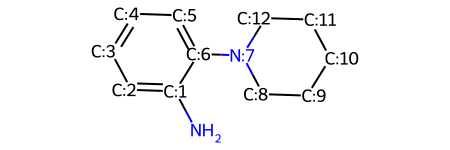

In [ ]:
df_new["Mol"][1]

##### Getting the node feature matrix: feature 1: atomic number; feature 2: degree of the atoms; feature 3: Number of implicit hydrogen; feature 4: checking whether the atom is part of ring and feature 5: whether atom is aromatic or not

In [ ]:
def node_feature(atom):
    return [atom.GetAtomicNum(),
          atom.GetDegree(),
          atom.GetNumImplicitHs(),
            atom.IsInRing(),
            atom.GetIsAromatic()]

def node_feature_matrix(molecule):
    node_matrix = []
    for atoms in molecule.GetAtoms():
        node_matrix.append(node_feature(atoms))
    return torch.tensor(node_matrix, dtype = torch.float)

df_new["node_matrix"] = df_new["idx_mol"].apply(lambda x: node_feature_matrix(x))
#df.head()
df_new["node_matrix"][1]

tensor([[7., 1., 2., 0., 0.],
        [6., 3., 0., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 3., 0., 1., 1.],
        [7., 3., 0., 1., 0.],
        [6., 2., 2., 1., 0.],
        [6., 2., 2., 1., 0.],
        [6., 2., 2., 1., 0.],
        [6., 2., 2., 1., 0.],
        [6., 2., 2., 1., 0.]])

In [ ]:
# first_col = df_new["node_matrix"][1][:,0]
# first_col

In [ ]:
df_new["node_matrix"]

,node_matrix
0,"[[tensor(8.), tensor(1.), tensor(0.), tensor(0..."
1,"[[tensor(7.), tensor(1.), tensor(2.), tensor(0..."
2,"[[tensor(6.), tensor(2.), tensor(1.), tensor(1..."
3,"[[tensor(8.), tensor(1.), tensor(1.), tensor(0..."
4,"[[tensor(7.), tensor(1.), tensor(2.), tensor(0..."
...,...
25960,"[[tensor(6.), tensor(1.), tensor(3.), tensor(0..."
25961,"[[tensor(6.), tensor(1.), tensor(3.), tensor(0..."
25962,"[[tensor(6.), tensor(2.), tensor(1.), tensor(1..."
25963,"[[tensor(6.), tensor(2.), tensor(1.), tensor(1..."


In [ ]:
#for matrix in df_new["node_matrix"]:
max_val = max(matrix[:, 0].max().item() for matrix in df_new['node_matrix'])
print("The highest atomic number present in the dataset is:", max_val)



The highest atomic number present in the dataset is: 82.0


In [ ]:
for i in range(1,83):
  count = sum((t[:, 0] == i).any().item() for t in df_new["node_matrix"])

  print(f"Number of compounds with element of atomic number {i} present is: {count}")


Number of compounds with element of atomic number 1 present is: 21
Number of compounds with element of atomic number 2 present is: 0
Number of compounds with element of atomic number 3 present is: 0
Number of compounds with element of atomic number 4 present is: 0
Number of compounds with element of atomic number 5 present is: 241
Number of compounds with element of atomic number 6 present is: 25890
Number of compounds with element of atomic number 7 present is: 13370
Number of compounds with element of atomic number 8 present is: 19766
Number of compounds with element of atomic number 9 present is: 2473
Number of compounds with element of atomic number 10 present is: 0
Number of compounds with element of atomic number 11 present is: 2
Number of compounds with element of atomic number 12 present is: 1
Number of compounds with element of atomic number 13 present is: 1
Number of compounds with element of atomic number 14 present is: 199
Number of compounds with element of atomic number 1

In [ ]:
df_new["node_matrix"][0]

tensor([[8., 1., 0., 0., 0.],
        [7., 3., 0., 0., 0.],
        [8., 1., 0., 0., 0.],
        [6., 3., 0., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 3., 0., 1., 1.],
        [6., 2., 2., 0., 0.],
        [6., 3., 0., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 2., 1., 1., 1.],
        [6., 2., 1., 1., 1.],
        [7., 2., 0., 1., 1.],
        [6., 3., 0., 1., 1.],
        [7., 3., 0., 0., 0.],
        [8., 1., 0., 0., 0.],
        [8., 1., 0., 0., 0.],
        [6., 2., 1., 1., 1.]])

In [ ]:
len(df_new)

25965

In [ ]:
import torch_geometric
from torch_geometric.data import Data

## Creating dataset for the model

In [ ]:
dataset = []
for _, row in df_new.iterrows():
    x = row["node_matrix"]
    edge_index = row["coo_matrix"]
    y = torch.tensor([row["mpC"]], dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, y=y)
    dataset.append(data)

dataset


[Data(x=[19, 5], edge_index=[2, 40], y=[1]),
 Data(x=[13, 5], edge_index=[2, 28], y=[1]),
 Data(x=[12, 5], edge_index=[2, 26], y=[1]),
 Data(x=[13, 5], edge_index=[2, 28], y=[1]),
 Data(x=[9, 5], edge_index=[2, 18], y=[1]),
 Data(x=[19, 5], edge_index=[2, 38], y=[1]),
 Data(x=[21, 5], edge_index=[2, 44], y=[1]),
 Data(x=[20, 5], edge_index=[2, 40], y=[1]),
 Data(x=[7, 5], edge_index=[2, 12], y=[1]),
 Data(x=[11, 5], edge_index=[2, 24], y=[1]),
 Data(x=[18, 5], edge_index=[2, 42], y=[1]),
 Data(x=[4, 5], edge_index=[2, 6], y=[1]),
 Data(x=[12, 5], edge_index=[2, 26], y=[1]),
 Data(x=[13, 5], edge_index=[2, 28], y=[1]),
 Data(x=[12, 5], edge_index=[2, 26], y=[1]),
 Data(x=[12, 5], edge_index=[2, 26], y=[1]),
 Data(x=[10, 5], edge_index=[2, 20], y=[1]),
 Data(x=[5, 5], edge_index=[2, 8], y=[1]),
 Data(x=[16, 5], edge_index=[2, 30], y=[1]),
 Data(x=[9, 5], edge_index=[2, 16], y=[1]),
 Data(x=[8, 5], edge_index=[2, 14], y=[1]),
 Data(x=[9, 5], edge_index=[2, 16], y=[1]),
 Data(x=[12, 5], ed

## Splitting into train and test dataset

In [ ]:
import random

random.seed(13)
data = random.sample(dataset, len(dataset))

train_dataset = dataset[:25000]
test_dataset = dataset[25000:]

print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

Number of training graphs: 25000
Number of test graphs: 965


## Splitting to batches using dataloader

In [ ]:
from torch_geometric.loader import DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataloaders: {train_loader, test_loader}")
print(f"Length of train loader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Length of test loader: {len(test_loader)} batches of {BATCH_SIZE}")


# for step, data in enumerate(train_loader):
#     print(f'Step {step + 1}:')
#     print('=======')
#     print(f'Number of graphs in the current training batch: {data.num_graphs}')
#     print(data)
#     print()

# for step, data in enumerate(test_loader):
#     print(f'Step {step + 1}:')
#     print('=======')
#     print(f'Number of graphs in the current testing batch: {data.num_graphs}')
#     print(data)
#     print()

Dataloaders: (<torch_geometric.loader.dataloader.DataLoader object at 0x7f25d18fd610>, <torch_geometric.loader.dataloader.DataLoader object at 0x7f25d18df6e0>)
Length of train loader: 782 batches of 32
Length of test loader: 31 batches of 32


In [ ]:
print(len(train_loader))

782


In [ ]:
for i, batch in enumerate(train_loader):
    print(f"\n🔹 Batch {i+1}")
    print(f"Batch {batch}")
    print("Number of nodes:", batch.x.size(0))
    print("Number of edges:", batch.edge_index.size(1))
    print("Target shape:", batch.y.shape)
    print("Graphs in batch:", batch.num_graphs)
    print("Batch vector shape:", batch.batch.shape)

    if i == 4:   # Stop after 5 batches
        break



🔹 Batch 1
Batch DataBatch(x=[475, 5], edge_index=[2, 996], y=[32], batch=[475], ptr=[33])
Number of nodes: 475
Number of edges: 996
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([475])

🔹 Batch 2
Batch DataBatch(x=[481, 5], edge_index=[2, 988], y=[32], batch=[481], ptr=[33])
Number of nodes: 481
Number of edges: 988
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([481])

🔹 Batch 3
Batch DataBatch(x=[523, 5], edge_index=[2, 1098], y=[32], batch=[523], ptr=[33])
Number of nodes: 523
Number of edges: 1098
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([523])

🔹 Batch 4
Batch DataBatch(x=[453, 5], edge_index=[2, 932], y=[32], batch=[453], ptr=[33])
Number of nodes: 453
Number of edges: 932
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([453])

🔹 Batch 5
Batch DataBatch(x=[438, 5], edge_index=[2, 908], y=[32], batch=[438], ptr=[33])
Number of nodes: 43

In [ ]:
for i, batch in enumerate(test_loader):
    print(f"\n🔹 Batch {i+1}")
    print(f"Batch {batch}")
    print("Number of nodes:", batch.x.size(0))
    print("Number of edges:", batch.edge_index.size(1))
    print("Target shape:", batch.y.shape)
    print("Graphs in batch:", batch.num_graphs)
    print("Batch vector shape:", batch.batch.shape)

    if i == 4:   # Stop after 5 batches
        break


🔹 Batch 1
Batch DataBatch(x=[655, 5], edge_index=[2, 1408], y=[32], batch=[655], ptr=[33])
Number of nodes: 655
Number of edges: 1408
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([655])

🔹 Batch 2
Batch DataBatch(x=[821, 5], edge_index=[2, 1824], y=[32], batch=[821], ptr=[33])
Number of nodes: 821
Number of edges: 1824
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([821])

🔹 Batch 3
Batch DataBatch(x=[722, 5], edge_index=[2, 1592], y=[32], batch=[722], ptr=[33])
Number of nodes: 722
Number of edges: 1592
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([722])

🔹 Batch 4
Batch DataBatch(x=[587, 5], edge_index=[2, 1246], y=[32], batch=[587], ptr=[33])
Number of nodes: 587
Number of edges: 1246
Target shape: torch.Size([32])
Graphs in batch: 32
Batch vector shape: torch.Size([587])

🔹 Batch 5
Batch DataBatch(x=[649, 5], edge_index=[2, 1390], y=[32], batch=[649], ptr=[33])
Number of no

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [ ]:
from torch import nn
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool as gmp, global_max_pool as gap

## Model_0:(Took the same model used for ESOL dataset)

In [ ]:
class GCNModelV0(torch.nn.Module):
  def __init__(self, input_unit:int, hidden_unit:int, output_unit:int):
    super().__init__()
    self.conv1 = GCNConv(input_unit, hidden_unit)
    self.conv2 = GCNConv(hidden_unit, hidden_unit)
    self.conv3 = GCNConv(hidden_unit, hidden_unit)
    self.conv4 = GCNConv(hidden_unit, hidden_unit)
    self.linear = Linear(hidden_unit*2, 1)


  def forward(self, x, edge_index, batch):
    x = self.conv1(x, edge_index)
    x = F.tanh(x)
    x = self.conv2(x, edge_index)
    x = F.tanh(x)
    x = self.conv3(x, edge_index)
    x = F.tanh(x)
    x = self.conv4(x, edge_index)
    x = F.tanh(x)

    x = torch.cat([gmp(x, batch),
                            gap(x, batch)], dim=1)



    #x = F.dropout(x, p=0.5, training=self.training)

    x = self.linear(x)
    return x




torch.manual_seed(42)
model_0 = GCNModelV0(input_unit= 5, hidden_unit= 64, output_unit= 1)
print (model_0)

GCNModelV0(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (conv4): GCNConv(64, 64)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.0007)

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float):
    train_time =  end - start
    print(f"Total time taken for training: {train_time:.6f}seconds")
    return train_time

In [ ]:
def train_loop(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    train_loss = 0

    for batch in train_loader:
        model.train()

        ##Forwars pass
        y_pred = model(batch.x.float(), batch.edge_index, batch.batch)

        ## Calculate the loss
        loss = loss_fn(y_pred, batch.y.float())
        train_loss += loss


        ## Optimizer zero grad
        optimizer.zero_grad()

        ## Loss backward
        loss.backward()

        ## optimer step
        optimizer.step()

    train_loss /= len(train_loader)

    print(f" Train loss: {train_loss}")

In [ ]:
def test_loop(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer):
    test_loss = 0

    for batch in test_loader:

        test_pred = model(batch.x.float(), batch.edge_index, batch.batch)

        ## Calculate loss
        loss = loss_fn(test_pred, batch.y.float())
        test_loss += loss


    test_loss /= len(test_loader)

    print(f"Test_loss: {test_loss}")


In [ ]:
from tqdm.auto import tqdm ## FOR KEEPING THE progress bar
torch.manual_seed(42)
start_time = timer()
epochs = 20000

for epoch in tqdm(range(epochs)):
  if epoch % 1000 == 0:
    print(f"Epoch: {epoch}------------")
    train_loop(model_0, train_loader, loss_fn, optimizer)


    model_0.eval()
    with torch.inference_mode():
        test_loop(model_0, test_loader, loss_fn, optimizer)

end_time = timer()
total_time = end_time - start_time
print(f"The total time taken for the model to run is: {total_time}")



  0%|          | 0/20000 [00:00<?, ?it/s]

Epoch: 0------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


 Train loss: 12969.7734375


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([5])) that is different to the input size (torch.Size([5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Test_loss: 13503.5625
Epoch: 1000------------
 Train loss: 9317.908203125
Test_loss: 10214.017578125
Epoch: 2000------------
 Train loss: 8885.3359375
Test_loss: 9558.7294921875
Epoch: 3000------------
 Train loss: 8877.80859375
Test_loss: 9446.3388671875
Epoch: 4000------------
 Train loss: 8871.73046875
Test_loss: 9437.025390625
Epoch: 5000------------
 Train loss: 8875.146484375
Test_loss: 9488.4658203125
Epoch: 6000------------
 Train loss: 8868.7548828125
Test_loss: 9497.0419921875
Epoch: 7000------------
 Train loss: 8868.298828125
Test_loss: 9474.45703125
Epoch: 8000------------
 Train loss: 8875.0302734375
Test_loss: 9526.263671875
Epoch: 9000------------
 Train loss: 8872.734375
Test_loss: 9507.78125
Epoch: 10000------------
 Train loss: 8880.234375
Test_loss: 9493.1826171875
Epoch: 11000------------
 Train loss: 8870.13671875
Test_loss: 9522.759765625
Epoch: 12000------------
 Train loss: 8873.138671875
Test_loss: 9506.908203125
Epoch: 13000------------
 Train loss: 8877.0644

##My God!!!! Such a poor model.... Definitely needto improve it